# Figure 3 — GC-content bias is introduced by Gnocchi's regional adjustment, and tracks the DNM model's miscalibration

**Panel A.** Mean standardized rank of three constraint metrics, binned by GC content, over the same
GC axis. Two claims:

1. Full Gnocchi's rank climbs steeply with GC content — the bias reported in Fig. 2A.
2. The *context-only* step of the same model (step 1, the sequence-context mutation rate with the
   regional adjustment set to $r \equiv 1$) is not merely less biased — it is biased about as little
   as **depletion rank**, an independently constructed metric. So the GC bias is *introduced by the
   regional-feature adjustment*, not inherited from the sequence-context model underneath it.

**Panel B.** The calibration gap of the DNM model that produces that adjustment: mean fitted
$P(\text{DNM})$ minus the empirical DNM rate, over the same GC axis. The GC range where the DNM model
over-predicts is the GC range where full Gnocchi's rank runs high — miscalibration in the training-set
model translating directly into genome-wide bias.

## Provenance

| Curve | Window set | Source |
|---|---|---|
| Step 1 (context-only, $r{=}1$) | Chen 1kb windows | `expected_counts_by_context_methyl_genome_1kb.txt` (public bucket) |
| Full Gnocchi (step 2) | Chen 1kb windows | `fig_tables/constraint_z_genome_1kb.annot.txt` (public bucket) |
| Depletion rank | **Halldorsson windows** | Supplied BED — see the config cell |
| Panel B | DNM training sites | Refit of the per-context multivariate model (`gnocchi_bias.dnm_model`) |

Note the depletion-rank curve comes from a **different window set** (and a different window size) than
the two Gnocchi curves — they are not joined, each is ranked within itself. The rank statistic is
uniform on $(0,1)$ by construction for every curve, so what is being compared is how each model's
uniform mass redistributes across GC, not the scores' absolute values. The caption should say this.

All heavy computation is cached to `output/`; re-running this notebook after the first pass is fast.

In [1]:
%matplotlib inline
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

_HERE = os.path.dirname(os.path.abspath("__file__"))
_REPO_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "fig3" else os.path.abspath("..")
for p in (_REPO_ROOT, os.path.join(_REPO_ROOT, "fig3")):
    if p not in sys.path:
        sys.path.insert(0, p)

from gnocchi_bias import windows as W
import panels
import depletion_rank as dr

print("repo root:", _REPO_ROOT)

repo root: /Users/petermchale/gnomad_nc_constraint


## Configuration

`DEPLETION_RANK_BED` is the one input that is **not** in this repo. It comes from the constraint-tools
`CONSTRAINT_TOOLS_DATA` path used by
`papers/neutral_models_are_biased/9.regression/experiment.1.ipynb`:

```
{CONSTRAINT_TOOLS_DATA}/depletion_rank_scores/41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed
```

Copy it somewhere local and point `DEPLETION_RANK_BED` at it. Until then the notebook builds the
figure with the two Gnocchi curves and prints a notice — everything else works.

`GENEHANCER_BED` is the same situation for the enhancer-exclusion half of the "neutral" window
definition (GeneHancer is licensed and cannot be downloaded here). Leaving it `None` means "neutral"
is noncoding + `pass_qc` + autosome/PAR only, which is what the current Fig. 2A-style analysis uses.

In [2]:
CACHE_DIR = os.path.join(_REPO_ROOT, "tmp")            # shared bucket-download cache
OUTPUT_DIR = os.path.join(_HERE, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- inputs that must be supplied by hand (not fetchable here) ---
DEPLETION_RANK_BED = None   # e.g. "/path/to/41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed"
GENEHANCER_BED = None       # e.g. "/path/to/genehancer.bed"

# --- panel B input: the DNM model's binned calibration table ---
# Produced by: python dnm_training_size/run_dnm_training_experiment.py \
#                  -mode reliability -subsample_frac 1.0 -tag full
RELIABILITY_TABLE = os.path.join(
    _REPO_ROOT, "dnm_training_size", "output", "training_reliability_binned.dnm_refit_full.txt")

# Per-site predictions (context, gc, label, pred) from the same -mode reliability run.
# Needed for the CpG-stratified, ratio-scale panel B; the binned table above cannot be
# re-stratified after the fact because it has already pooled over context.
PREDICTIONS_TABLE = os.path.join(
    _REPO_ROOT, "dnm_training_size", "output",
    "training_reliability_predictions.dnm_refit_full.txt")

N_BINS = 20
# Bin-population floors. The extreme GC bins can hold a handful of windows/sites, where the mean is
# essentially noise and the error bar swamps the panel; these drop them. Panel B's floor is the
# `-min_n` that produced training_reliability_gap.*.wellpopulated.pdf.
MIN_N_PANEL_A = 100
MIN_N_PANEL_B = 1000
# The stratified panel needs its own, lower floor: splitting by CpG status leaves the
# CpG group with only ~500-1000 sites in the top GC bins, and those bins carry the
# result. 1000 would silently drop them. Their error bars show the uncertainty.
MIN_N_PANEL_B_STRATIFIED = 500

XRANGE = (0.2, 0.73)   # visually matched to Fig. 2A; see CLAUDE.md, "Axis ranges"
PANEL_A_CACHE = os.path.join(OUTPUT_DIR, "panelA_binned_ranks.parquet")
PANEL_A_META = os.path.join(OUTPUT_DIR, "panelA_meta.json")

## Panel A data — genome-wide 1kb windows

First run downloads ~1.9 GB (cached in `tmp/`) and takes a few minutes; the binned result is cached to
`output/`, so later runs are instant. Delete `PANEL_A_CACHE` to force a rebuild.

In [3]:
if os.path.exists(PANEL_A_CACHE) and os.path.exists(PANEL_A_META):
    binned_gnocchi = pl.read_parquet(PANEL_A_CACHE)
    meta = json.load(open(PANEL_A_META))
    print(f"loaded cached panel A: {meta['n_windows']:,} windows, mean GC = {meta['gc_mean']:.4f}")
else:
    df_win = W.build_window_table(
        CACHE_DIR,
        exclude_sex=True,          # McHale et al. Methods: X and Y omitted
        noncoding=True,            # half of the "neutral" definition
        apply_qc=True,             # Chen et al.'s own pass_qc
        genehancer_bed=GENEHANCER_BED,   # the other half; None = not applied
    )
    df_win, binned_gnocchi = W.binned_rank_curves(
        df_win,
        curves=[("step1", "expected_step1"), ("step2", "expected_step2")],
        n_bins=N_BINS,
    )
    meta = {"n_windows": df_win.height, "gc_mean": float(df_win["GC_content"].mean())}
    binned_gnocchi.write_parquet(PANEL_A_CACHE)
    json.dump(meta, open(PANEL_A_META, "w"), indent=2)
    print(f"built panel A: {meta['n_windows']:,} windows, mean GC = {meta['gc_mean']:.4f}")

binned_gnocchi

loaded cached panel A: 1,840,310 windows, mean GC = 0.3988


gc_bin,n,gc_mid,mean_step1,se_step1,mean_step2,se_step2
i64,u32,f64,f64,f64,f64,f64
0,2,0.157,0.133854,0.073397,0.338234,0.31193
1,41,0.19678,0.346163,0.041601,0.457317,0.049759
2,1210,0.236177,0.333394,0.006788,0.285144,0.006944
3,23714,0.268477,0.377781,0.001677,0.306085,0.001576
4,127703,0.300542,0.41977,0.000756,0.354876,0.000711
…,…,…,…,…,…,…
15,993,0.676921,0.335248,0.008938,0.856879,0.007291
16,503,0.712757,0.283838,0.012123,0.867125,0.009655
17,256,0.747621,0.261728,0.016675,0.877301,0.013496


## Depletion rank (third curve of panel A)

In [4]:
binned_dr = None
if DEPLETION_RANK_BED:
    df_dr = dr.load_depletion_rank_windows(DEPLETION_RANK_BED)
    binned_dr = dr.bin_depletion_rank(df_dr, n_bins=N_BINS)
    display(binned_dr)
else:
    print("DEPLETION_RANK_BED is not set -- building the figure without the depletion-rank curve.")
    print("Set it in the config cell to add the third curve; see that cell for the exact source path.")

DEPLETION_RANK_BED is not set -- building the figure without the depletion-rank curve.
Set it in the config cell to add the third curve; see that cell for the exact source path.


## Panel B data — the DNM model's calibration gap

`gc_mid` here is on this repo's native 0–100 percent scale; `panel_calibration_gap` divides by 100 so
both panels share a 0–1 GC axis. Both panels' GC content is that of a 1 kb window — panel A of the
Chen window itself, panel B of the 1 kb around each training site (the `GC_content_1k` regional
feature) — so the shared axis is the same quantity over two different populations.

In [5]:
from gnocchi_bias.dnm_model import bin_training_calibration

# Pooled (all contexts) -- the original panel B quantity, kept for comparison.
reliability = pd.read_csv(RELIABILITY_TABLE, sep="\t")
reliability["gap"] = reliability["mean_pred"] - reliability["empirical_prop"]

# CpG-stratified, from the per-site predictions.
preds = pd.read_csv(PREDICTIONS_TABLE, sep="\t")
print(f"{len(preds):,} per-site predictions, {preds.context.nunique()} contexts")
calib = bin_training_calibration(preds, n_bins=N_BINS, stratify_cpg=True)
calib[calib.n >= MIN_N_PANEL_B_STRATIFIED][
    ["group","n","gc_mid","mean_pred","empirical_prop","gap","inflation"]
].round(4)

4,503,034 per-site predictions, 32 contexts


,group,n,gc_mid,mean_pred,empirical_prop,gap,inflation
2,CpG,1745,28.3826,0.5309,0.5576,-0.0267,0.9521
3,CpG,8246,31.9487,0.5305,0.5427,-0.0122,0.9775
4,CpG,19267,35.7125,0.5306,0.5392,-0.0085,0.9841
5,CpG,28096,39.3955,0.5302,0.5303,-0.0002,0.9997
6,CpG,28944,43.1708,0.5298,0.5288,0.0010,1.0018
7,CpG,23133,46.9998,0.5309,0.5281,0.0029,1.0054
8,CpG,15182,50.7982,0.5327,0.5354,-0.0027,0.9949
9,CpG,9344,54.6514,0.5343,0.5319,0.0024,1.0045
10,CpG,6085,58.5842,0.5315,0.5568,-0.0252,0.9547
11,CpG,3700,62.3770,0.5307,0.5530,-0.0223,0.9597


## The figure

wrote /Users/petermchale/gnomad_nc_constraint/fig3/output/fig3.pdf


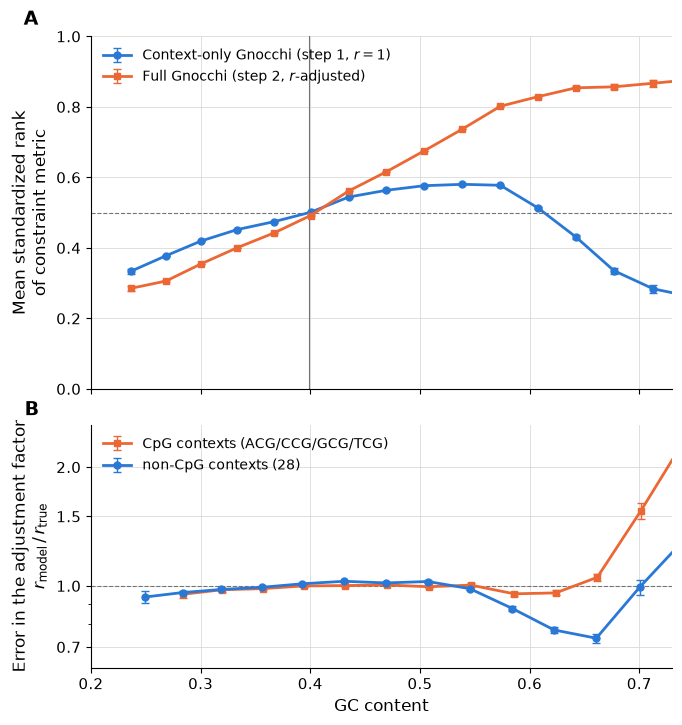

In [6]:
curves = [
    panels.curve_from_binned(binned_gnocchi, "step1", "step1",
                              "Context-only Gnocchi (step 1, $r{=}1$)"),
    panels.curve_from_binned(binned_gnocchi, "step2", "step2",
                              "Full Gnocchi (step 2, $r$-adjusted)"),
]
if binned_dr is not None:
    curves.append(panels.curve_from_binned(binned_dr, "dr", "dr",
                                            "Depletion rank (Halldorsson windows)"))

fig, (axA, axB) = plt.subplots(
    2, 1, figsize=(7.5, 8.2), sharex=True,
    gridspec_kw={"height_ratios": [1.45, 1], "hspace": 0.12},
)

# yrange=(0, 1) matches Fig. 2A exactly; pass e.g. yrange=(0.2, 0.95) to reclaim the
# dead space below the curves if the stacked figure needs the room.
panels.panel_rank_bias(axA, curves, gc_mean=meta["gc_mean"], xrange=XRANGE,
                        min_n=MIN_N_PANEL_A, show_xlabel=False)
# Panel B: the multiplicative error in r(w), stratified by CpG status.
# panels.panel_calibration_gap(axB, reliability, ...) draws the older pooled,
# absolute-gap version instead -- see the markdown below for why it was replaced.
panels.panel_calibration_ratio(axB, calib, min_n=MIN_N_PANEL_B_STRATIFIED,
                                xrange=XRANGE, show_xlabel=True)
panels.label_panels([axA, axB])

fig.savefig(os.path.join(OUTPUT_DIR, "fig3.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUTPUT_DIR, "fig3.png"), dpi=200, bbox_inches="tight")
print("wrote", os.path.join(OUTPUT_DIR, "fig3.pdf"))

## Numbers for the caption

In [7]:
b = binned_gnocchi.filter(pl.col("n") >= MIN_N_PANEL_A)
print(f"panel A: {meta['n_windows']:,} windows, mean GC {meta['gc_mean']:.3f}, "
      f"{b.height} bins with n >= {MIN_N_PANEL_A}")
print(f"  step 1 mean rank spans {b['mean_step1'].min():.3f} - {b['mean_step1'].max():.3f}")
print(f"  step 2 mean rank spans {b['mean_step2'].min():.3f} - {b['mean_step2'].max():.3f}")
if binned_dr is not None:
    d = binned_dr.filter(pl.col("n") >= MIN_N_PANEL_A)
    print(f"  depletion rank spans {d['mean_dr'].min():.3f} - {d['mean_dr'].max():.3f}")

# Deviation from the unbiased value of 0.5 -- the single number that says
# "step 1 is as unbiased as depletion rank, and full Gnocchi is not".
for label in (["step1", "step2"]):
    mad = (b[f"mean_{label}"] - 0.5).abs().mean()
    print(f"  mean |rank - 0.5| across bins, {label}: {mad:.4f}")
if binned_dr is not None:
    mad = (d["mean_dr"] - 0.5).abs().mean()
    print(f"  mean |rank - 0.5| across bins, depletion rank: {mad:.4f}")

r = reliability[reliability["n"] >= MIN_N_PANEL_B]
print(f"\npanel B: {len(r)} bins with n >= {MIN_N_PANEL_B:,}, "
      f"{r['n'].sum():,} training sites")
print(f"  calibration gap spans {r['gap'].min():+.4f} - {r['gap'].max():+.4f}")

panel A: 1,840,310 windows, mean GC 0.399, 16 bins with n >= 100
  step 1 mean rank spans 0.262 - 0.580
  step 2 mean rank spans 0.285 - 0.877
  mean |rank - 0.5| across bins, step1: 0.0929
  mean |rank - 0.5| across bins, step2: 0.2122

panel B: 14 bins with n >= 1,000, 4,502,090 training sites
  calibration gap spans -0.0312 - +0.1171
